In [1]:
import pandas as pd
import os
import numpy as np

In [23]:
import os
import re
import pandas as pd
import random

def extract_k_value(filename):
    # Extract k value from filename using regex (e.g., k11 from roy2.html.exe_SpectralCoCluster_AugmentedKMeansDBSCANSoft_k11.yara)
    match = re.search(r'_k(\d+)\.yara$', filename)
    return int(match.group(1)) if match else None

def find_best_k_value(cluster_path):
    # List subdirectories in the cluster folder
    subdirs = [d for d in os.listdir(cluster_path) if os.path.isdir(os.path.join(cluster_path, d))]
    
    # Check for TrueBEST_K_* directory
    true_best_dir = [d for d in subdirs if d.startswith('TrueBEST_K_')]
    if true_best_dir:
        true_best_path = os.path.join(cluster_path, true_best_dir[0])
        # Find .yara file in TrueBEST_K_* directory
        for file in os.listdir(true_best_path):
            if file.endswith('.yara'):
                k_value = extract_k_value(file)
                if k_value is not None:
                    return k_value
    
    # Fallback to TOP_K_CANDIATE* directory
    top_k_dirs = [d for d in subdirs if d.startswith('TOP_K_CANDIATE')]
    if top_k_dirs:
        top_k_path = os.path.join(cluster_path, top_k_dirs[0])  # Pick first TOP_K_CANDIATE
        for file in os.listdir(top_k_path):
            if file.endswith('.yara'):
                k_value = extract_k_value(file)
                if k_value is not None:
                    return k_value
    
    # If neither exists, randomly pick one of the *iKsearch folders
    iksearch_dirs = [d for d in subdirs if d.endswith('_iKsearch')]
    if iksearch_dirs:
        random_iksearch = random.choice(iksearch_dirs)
        iksearch_path = os.path.join(cluster_path, random_iksearch)
        for file in os.listdir(iksearch_path):
            if file.endswith('.yara'):
                k_value = extract_k_value(file)
                if k_value is not None:
                    return k_value
    
    # If no valid k value is found, return None or handle as needed
    return None

def process_clusters(root_folder):
    # Initialize DataFrame
    df = pd.DataFrame(columns=['cluster_number', 'best_k_value'])
    
    # List all cluster_* folders
    cluster_dirs = [d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d)) and d.startswith('cluster_')]
    
    for cluster_dir in cluster_dirs:
        # Extract cluster number from folder name (e.g., cluster_0 -> 0)
        cluster_num = int(re.search(r'cluster_(\d+)', cluster_dir).group(1))
        cluster_path = os.path.join(root_folder, cluster_dir)
        
        # Find best k value for this cluster
        best_k = find_best_k_value(cluster_path)
        
        # Append to DataFrame if a valid k value was found
        if best_k is not None:
            df = pd.concat([df, pd.DataFrame([{'cluster_number': cluster_num, 'best_k_value': best_k}])], ignore_index=True)
    
    return df


In [24]:
root_folder = "/home/mabon/research/Autoyara/AutoPYara/AutoPYara/YaraTest/BestPYara/"  # Replace with actual path
result_df = process_clusters(root_folder)


In [25]:
result_df

,cluster_number,best_k_value
0,905,1
1,1894,1
2,1396,1
3,254,1
4,1062,1
...,...,...
1051,764,20
1052,1905,1
1053,321,39
1054,1551,1


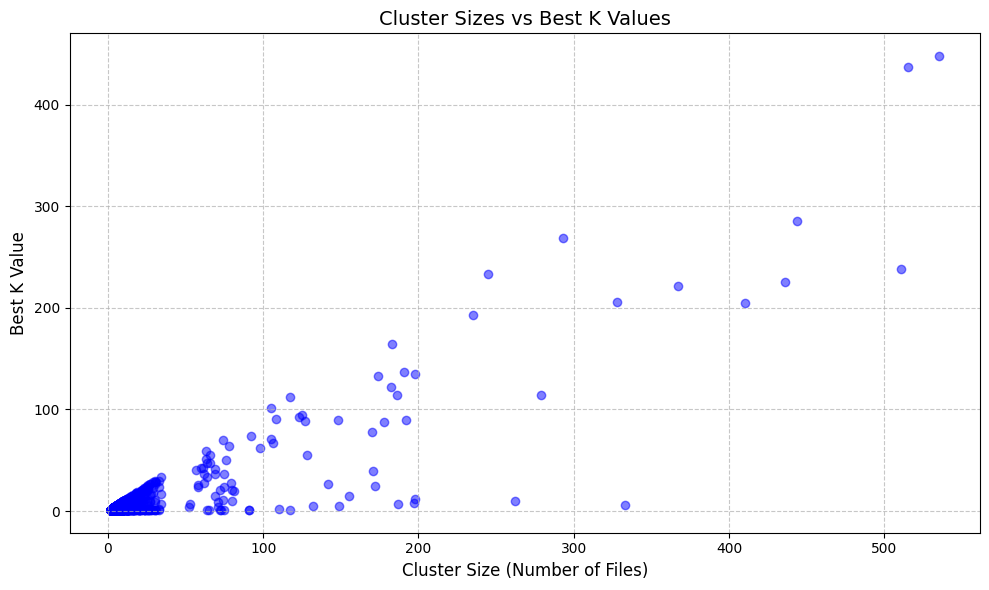

In [3]:
import os
import re
import pandas as pd
import random
import matplotlib.pyplot as plt

def extract_k_value(filename):
    # Extract k value from filename using regex (e.g., k11 from roy2.html.exe_SpectralCoCluster_AugmentedKMeansDBSCANSoft_k11.yara)
    match = re.search(r'_k(\d+)\.yara$', filename)
    return int(match.group(1)) if match else None

def find_best_k_value(cluster_path):
    # List subdirectories in the cluster folder
    subdirs = [d for d in os.listdir(cluster_path) if os.path.isdir(os.path.join(cluster_path, d))]
    
    # Check for TrueBEST_K_* directory
    true_best_dir = [d for d in subdirs if d.startswith('TrueBEST_K_')]
    if true_best_dir:
        true_best_path = os.path.join(cluster_path, true_best_dir[0])
        for file in os.listdir(true_best_path):
            if file.endswith('.yara'):
                k_value = extract_k_value(file)
                if k_value is not None:
                    return k_value
    
    # Fallback to TOP_K_CANDIATE* directory
    top_k_dirs = [d for d in subdirs if d.startswith('TOP_K_CANDIATE')]
    if top_k_dirs:
        top_k_path = os.path.join(cluster_path, top_k_dirs[0])
        for file in os.listdir(top_k_path):
            if file.endswith('.yara'):
                k_value = extract_k_value(file)
                if k_value is not None:
                    return k_value
    
    # If neither exists, randomly pick one of the *iKsearch folders
    iksearch_dirs = [d for d in subdirs if d.endswith('_iKsearch')]
    if iksearch_dirs:
        random_iksearch = random.choice(iksearch_dirs)
        iksearch_path = os.path.join(cluster_path, random_iksearch)
        for file in os.listdir(iksearch_path):
            if file.endswith('.yara'):
                k_value = extract_k_value(file)
                if k_value is not None:
                    return k_value
    
    # If no valid k value is found, return None
    return None

def process_clusters(root_folder):
    # Initialize DataFrame
    df = pd.DataFrame(columns=['cluster_number', 'best_k_value'])
    
    # List all cluster_* folders
    cluster_dirs = [d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d)) and d.startswith('cluster_')]
    
    for cluster_dir in cluster_dirs:
        # Extract cluster number from folder name (e.g., cluster_0 -> 0)
        cluster_num = int(re.search(r'cluster_(\d+)', cluster_dir).group(1))
        cluster_path = os.path.join(root_folder, cluster_dir)
        
        # Find best k value for this cluster
        best_k = find_best_k_value(cluster_path)
        
        # Append to DataFrame if a valid k value was found
        if best_k is not None:
            df = pd.concat([df, pd.DataFrame([{'cluster_number': cluster_num, 'best_k_value': best_k}])], ignore_index=True)
    
    return df

def get_files_by_all_clusters(df):
    """
    Get all file paths organized by their cluster labels.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing File_Path and Cluster_Label columns
    
    Returns:
    dict: Dictionary where keys are cluster labels and values are lists of file paths
    """
    cluster_files_dict = df.groupby('Cluster_Label')['File_Path'].apply(list).to_dict()
    return cluster_files_dict

# Main execution
root_folder = "/home/mabon/research/Autoyara/YaraResults/yaraRules/originalBloomFilters/virusTotal/BestKyara/"
result_df = process_clusters(root_folder)

# Load cluster data
df = pd.read_csv('/home/mabon/research/Autoyara/YaraResults/clusterCSV/virusTotal/MainVtCluster.csv')

# Get files from all clusters
all_cluster_files = get_files_by_all_clusters(df)

# Filter out clusters with fewer than two elements
valid_clusters = {k: v for k, v in all_cluster_files.items() if len(v) >= 2}

df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')

# Get labels, dropping any NaN
labels = df['Cluster_Label'].dropna().astype(int).tolist()

# Calculate cluster sizes
cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}

# Filter clusters that exist in both result_df and cluster_sizes with size >= 2
valid_cluster_numbers = [cluster_num for cluster_num in cluster_sizes.keys() 
                        if cluster_num in result_df['cluster_number'].values and cluster_sizes[cluster_num] >= 2]

# Create aligned lists for plotting
filtered_sizes = [cluster_sizes[cluster_num] for cluster_num in valid_cluster_numbers]
filtered_k_values = [result_df[result_df['cluster_number'] == cluster_num]['best_k_value'].iloc[0] 
                    for cluster_num in valid_cluster_numbers]

# Verify lists are the same length
if len(filtered_sizes) != len(filtered_k_values):
    raise ValueError(f"filtered_sizes (length {len(filtered_sizes)}) and filtered_k_values (length {len(filtered_k_values)}) must have the same length")

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(filtered_sizes, filtered_k_values, c='blue', alpha=0.5)

# Set plot title and labels
plt.title('Cluster Sizes vs Best K Values', fontsize=14)
plt.xlabel('Cluster Size (Number of Files)', fontsize=12)
plt.ylabel('Best K Value', fontsize=12)

# Show grid
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the plot
plt.savefig('cluster_sizes_vs_k_values.png')

# Show the plot
plt.show()

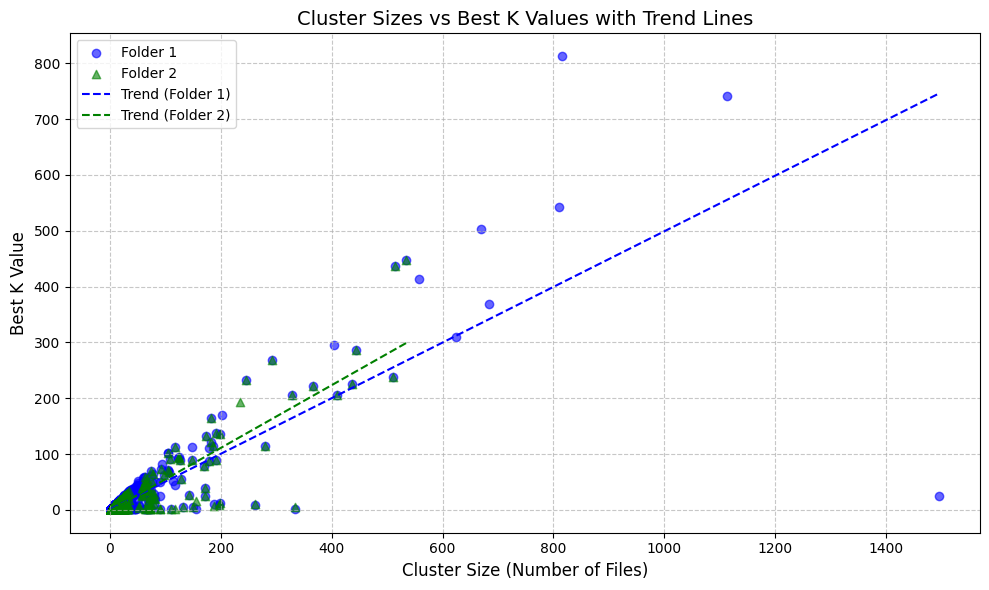

In [7]:
import os
import re
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np

def extract_k_value(filename):
    match = re.search(r'_k(\d+)\.yara$', filename)
    return int(match.group(1)) if match else None

def find_best_k_value(cluster_path):
    subdirs = [d for d in os.listdir(cluster_path) if os.path.isdir(os.path.join(cluster_path, d))]

    true_best_dir = [d for d in subdirs if d.startswith('TrueBEST_K_')]
    if true_best_dir:
        for file in os.listdir(os.path.join(cluster_path, true_best_dir[0])):
            if file.endswith('.yara'):
                return extract_k_value(file)

    top_k_dirs = [d for d in subdirs if d.startswith('TOP_K_CANDIATE')]
    if top_k_dirs:
        for file in os.listdir(os.path.join(cluster_path, top_k_dirs[0])):
            if file.endswith('.yara'):
                return extract_k_value(file)

    iksearch_dirs = [d for d in subdirs if d.endswith('_iKsearch')]
    if iksearch_dirs:
        random_iksearch = random.choice(iksearch_dirs)
        for file in os.listdir(os.path.join(cluster_path, random_iksearch)):
            if file.endswith('.yara'):
                return extract_k_value(file)

    return None

def process_clusters(root_folder):
    df = pd.DataFrame(columns=['cluster_number', 'best_k_value'])
    cluster_dirs = [d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d)) and d.startswith('cluster_')]

    for cluster_dir in cluster_dirs:
        cluster_num = int(re.search(r'cluster_(\d+)', cluster_dir).group(1))
        cluster_path = os.path.join(root_folder, cluster_dir)
        best_k = find_best_k_value(cluster_path)
        if best_k is not None:
            df = pd.concat([df, pd.DataFrame([{'cluster_number': cluster_num, 'best_k_value': best_k}])], ignore_index=True)

    return df

def get_cluster_sizes(df):
    df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')
    labels = df['Cluster_Label'].dropna().astype(int).tolist()
    return {label: labels.count(label) for label in set(labels) if label >= 0}

def prepare_plot_data(result_df, cluster_sizes):
    valid_cluster_numbers = [
        cluster_num for cluster_num in cluster_sizes
        if cluster_num in result_df['cluster_number'].values and cluster_sizes[cluster_num] >= 2
    ]
    sizes = [cluster_sizes[num] for num in valid_cluster_numbers]
    k_values = [result_df[result_df['cluster_number'] == num]['best_k_value'].iloc[0] for num in valid_cluster_numbers]
    return sizes, k_values

# === Paths to your folders ===
root_folder1 = "/home/mabon/research/Autoyara/AutoPYara/AutoPYara/YaraTest/BestPYara/"
root_folder2 = "/home/mabon/research/Autoyara/YaraResults/yaraRules/originalBloomFilters/virusTotal/BestKyara"
cluster_csv = '/home/mabon/research/Autoyara/YaraResults/clusterCSV/virusTotal/MainVtCluster.csv'

# === Load cluster info ===
df_cluster = pd.read_csv(cluster_csv)
cluster_sizes = get_cluster_sizes(df_cluster)

# === Process cluster results from both folders ===
result_df_1 = process_clusters(root_folder1)
result_df_2 = process_clusters(root_folder2)

sizes_1, k_vals_1 = prepare_plot_data(result_df_1, cluster_sizes)
sizes_2, k_vals_2 = prepare_plot_data(result_df_2, cluster_sizes)

# === Plot ===
plt.figure(figsize=(10, 6))

# Scatter points
plt.scatter(sizes_1, k_vals_1, c='blue', label='Folder 1', marker='o', alpha=0.6)
plt.scatter(sizes_2, k_vals_2, c='green', label='Folder 2', marker='^', alpha=0.6)

# Regression line for Folder 1
if len(sizes_1) >= 2:
    coeffs_1 = np.polyfit(sizes_1, k_vals_1, 1)
    poly1d_fn1 = np.poly1d(coeffs_1)
    x_range_1 = np.linspace(min(sizes_1), max(sizes_1), 100)
    plt.plot(x_range_1, poly1d_fn1(x_range_1), '--', color='blue', label='Trend (Folder 1)')

# Regression line for Folder 2
if len(sizes_2) >= 2:
    coeffs_2 = np.polyfit(sizes_2, k_vals_2, 1)
    poly1d_fn2 = np.poly1d(coeffs_2)
    x_range_2 = np.linspace(min(sizes_2), max(sizes_2), 100)
    plt.plot(x_range_2, poly1d_fn2(x_range_2), '--', color='green', label='Trend (Folder 2)')

# Plot formatting
plt.title('Cluster Sizes vs Best K Values with Trend Lines', fontsize=14)
plt.xlabel('Cluster Size (Number of Files)', fontsize=12)
plt.ylabel('Best K Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('cluster_sizes_vs_k_values_with_trends.png')
plt.show()


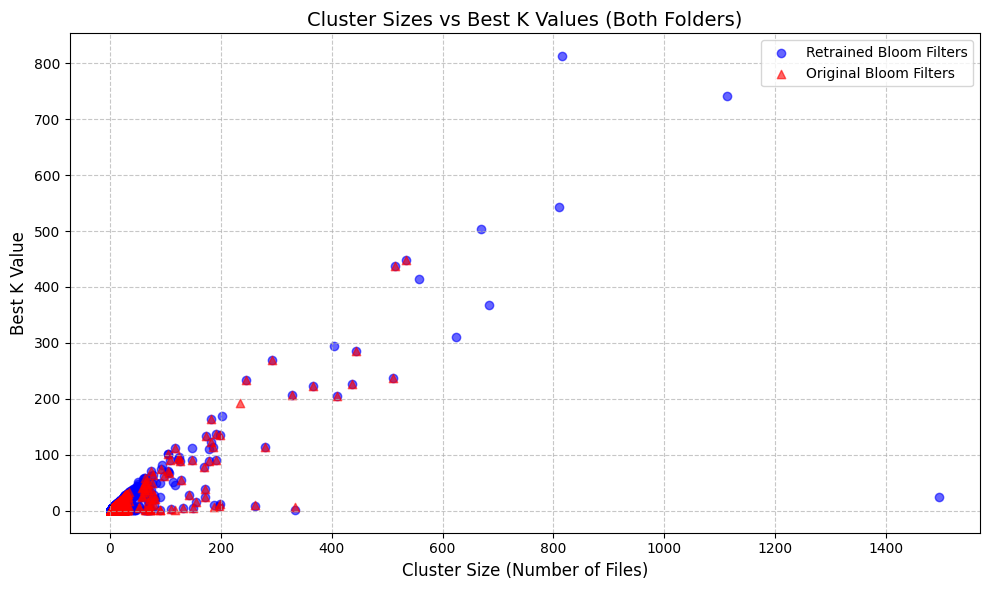

In [6]:
import os
import re
import pandas as pd
import random
import matplotlib.pyplot as plt

def extract_k_value(filename):
    match = re.search(r'_k(\d+)\.yara$', filename)
    return int(match.group(1)) if match else None

def find_best_k_value(cluster_path):
    subdirs = [d for d in os.listdir(cluster_path) if os.path.isdir(os.path.join(cluster_path, d))]
    
    true_best_dir = [d for d in subdirs if d.startswith('TrueBEST_K_')]
    if true_best_dir:
        for file in os.listdir(os.path.join(cluster_path, true_best_dir[0])):
            if file.endswith('.yara'):
                return extract_k_value(file)

    top_k_dirs = [d for d in subdirs if d.startswith('TOP_K_CANDIATE')]
    if top_k_dirs:
        for file in os.listdir(os.path.join(cluster_path, top_k_dirs[0])):
            if file.endswith('.yara'):
                return extract_k_value(file)

    iksearch_dirs = [d for d in subdirs if d.endswith('_iKsearch')]
    if iksearch_dirs:
        random_iksearch = random.choice(iksearch_dirs)
        for file in os.listdir(os.path.join(cluster_path, random_iksearch)):
            if file.endswith('.yara'):
                return extract_k_value(file)

    return None

def process_clusters(root_folder):
    df = pd.DataFrame(columns=['cluster_number', 'best_k_value'])
    cluster_dirs = [d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d)) and d.startswith('cluster_')]
    
    for cluster_dir in cluster_dirs:
        cluster_num = int(re.search(r'cluster_(\d+)', cluster_dir).group(1))
        cluster_path = os.path.join(root_folder, cluster_dir)
        best_k = find_best_k_value(cluster_path)
        if best_k is not None:
            df = pd.concat([df, pd.DataFrame([{'cluster_number': cluster_num, 'best_k_value': best_k}])], ignore_index=True)
    
    return df

def get_cluster_sizes(df):
    df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')
    labels = df['Cluster_Label'].dropna().astype(int).tolist()
    return {label: labels.count(label) for label in set(labels) if label >= 0}

def prepare_plot_data(result_df, cluster_sizes):
    valid_cluster_numbers = [
        cluster_num for cluster_num in cluster_sizes
        if cluster_num in result_df['cluster_number'].values and cluster_sizes[cluster_num] >= 2
    ]
    sizes = [cluster_sizes[num] for num in valid_cluster_numbers]
    k_values = [result_df[result_df['cluster_number'] == num]['best_k_value'].iloc[0] for num in valid_cluster_numbers]
    return sizes, k_values

# === Define input folders ===
root_folder1 = "/home/mabon/research/Autoyara/AutoPYara/AutoPYara/YaraTest/BestPYara/"
root_folder2 = "/home/mabon/research/Autoyara/YaraResults/yaraRules/originalBloomFilters/virusTotal/BestKyara"

# === Process both folders ===
result_df_1 = process_clusters(root_folder1)
result_df_2 = process_clusters(root_folder2)

# === Load cluster metadata for file counts ===
cluster_csv = '/home/mabon/research/Autoyara/YaraResults/clusterCSV/virusTotal/MainVtCluster.csv'
df_cluster = pd.read_csv(cluster_csv)
cluster_sizes = get_cluster_sizes(df_cluster)

# === Prepare plotting data ===
sizes_1, k_vals_1 = prepare_plot_data(result_df_1, cluster_sizes)
sizes_2, k_vals_2 = prepare_plot_data(result_df_2, cluster_sizes)

# === Plot ===
plt.figure(figsize=(10, 6))

plt.scatter(sizes_1, k_vals_1, c='blue', label='Retrained Bloom Filters', marker='o', alpha=0.6)
plt.scatter(sizes_2, k_vals_2, c='red', label='Original Bloom Filters', marker='^', alpha=0.6)

plt.title('Cluster Sizes vs Best K Values (Both Folders)', fontsize=14)
plt.xlabel('Cluster Size (Number of Files)', fontsize=12)
plt.ylabel('Best K Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('cluster_sizes_vs_k_values_both_folders.png')
plt.show()
